In [207]:
import torch
import torch.nn.functional as F

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce GTX 1660


## User Tower

In [ ]:
import uuid

In [131]:
class UserTower(torch.nn.Module):
    def __init__(self, output_dim: int, input_dim: int = 4):
        super().__init__()
        self.layer_1 = torch.nn.Linear(input_dim, output_dim)
    
    def forward(self, x: torch.Tensor):
        out = self.layer_1(x)
        return out

def process_user_id(user_id: uuid.UUID) -> torch.Tensor:
    return torch.frombuffer(user_id.bytes_le, dtype=torch.int32).to(dtype=torch.float32).unsqueeze(0)

In [ ]:
output_size = 8

user_tower = UserTower(output_size)
user_tower

UserTower(
  (layer_1): Linear(in_features=4, out_features=8, bias=True)
)

In [133]:
user_id = uuid.UUID(int=0)
user_x = process_user_id(user_id)
print(user_x.shape)
user_x

torch.Size([1, 4])


tensor([[0., 0., 0., 0.]])

In [134]:
with torch.no_grad():
    user_embedding = user_tower(user_x)
    print(user_embedding)

tensor([[-0.1834, -0.1462, -0.3635, -0.2819,  0.0168,  0.3761, -0.3718,  0.4282]])


## Item Tower

In [135]:
import os
import onnxruntime as ort
from onnxruntime import InferenceSession
from transformers import CLIPImageProcessor
from PIL import Image, ImageFile
import numpy as np

In [136]:
class ItemTower(torch.nn.Module):
    def __init__(self, output_dim: int, input_dim: int = 512):
        super().__init__()
        self.layer_1 = torch.nn.Linear(input_dim, output_dim)
    
    def forward(self, x: torch.Tensor):
        out = self.layer_1(x)
        return out

def process_image(image: ImageFile, processor: CLIPImageProcessor, clip_model: InferenceSession) -> torch.Tensor:
    image_arr = processor(image)['pixel_values'][0]
    image_features = torch.as_tensor(np.asarray(clip_model.run(None, {"images": [image_arr]})[0]))
    return image_features / image_features.norm(dim=-1, keepdim=True)

In [137]:
output_size = 8

item_tower = ItemTower(output_size)
item_tower

ItemTower(
  (layer_1): Linear(in_features=512, out_features=8, bias=True)
)

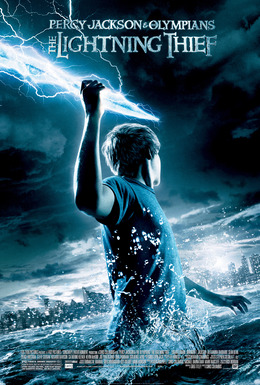

In [138]:
destination = "../semantic_search/clip_models"
clip_vision_path = os.path.join(destination, "onnx", "clip_vis_quant.onnx")
session_opts = ort.SessionOptions()
providers = ["CPUExecutionProvider"]

clip_vision_session = InferenceSession(
                clip_vision_path,
                session_opts,
                providers=providers
            )
processor = CLIPImageProcessor.from_pretrained(destination)

image = Image.open("../semantic_search/imgs/percy.jpg")
image

In [139]:
item_x = process_image(image, processor, clip_vision_session)
item_x.shape

torch.Size([1, 512])

In [140]:
with torch.no_grad():
    item_embedding = item_tower(item_x)
    print(item_embedding)

tensor([[ 0.0222, -0.0415, -0.0263,  0.0162, -0.0141,  0.0410,  0.0021,  0.0088]])


## Loss Function

In [149]:
criterion = torch.nn.CosineEmbeddingLoss()

In [174]:
torch.vstack([user_embedding, user_embedding])

tensor([[-0.1834, -0.1462, -0.3635, -0.2819,  0.0168,  0.3761, -0.3718,  0.4282],
        [-0.1834, -0.1462, -0.3635, -0.2819,  0.0168,  0.3761, -0.3718,  0.4282]])

In [ ]:
labels = torch.tensor([1, 1], dtype=torch.float32)
criterion(torch.vstack([user_embedding, item_embedding]), torch.vstack([item_embedding, item_embedding]), labels)

tensor(0.2945)

In [ ]:
labels = torch.tensor([-1], dtype=torch.float32)
criterion(torch.vstack([user_embedding]), torch.vstack([item_embedding]), labels)

tensor(0.4109)

In [170]:
user_embedding

tensor([[-0.1834, -0.1462, -0.3635, -0.2819,  0.0168,  0.3761, -0.3718,  0.4282]])

In [191]:
user_embedding.T @ item_embedding

tensor([[-4.0795e-03,  7.6050e-03,  4.8304e-03, -2.9691e-03,  2.5946e-03,
         -7.5224e-03, -3.8992e-04, -1.6137e-03],
        [-3.2518e-03,  6.0620e-03,  3.8504e-03, -2.3667e-03,  2.0682e-03,
         -5.9962e-03, -3.1081e-04, -1.2863e-03],
        [-8.0852e-03,  1.5072e-02,  9.5734e-03, -5.8845e-03,  5.1423e-03,
         -1.4909e-02, -7.7279e-04, -3.1983e-03],
        [-6.2716e-03,  1.1691e-02,  7.4260e-03, -4.5646e-03,  3.9888e-03,
         -1.1565e-02, -5.9944e-04, -2.4809e-03],
        [ 3.7429e-04, -6.9776e-04, -4.4319e-04,  2.7242e-04, -2.3806e-04,
          6.9018e-04,  3.5775e-05,  1.4806e-04],
        [ 8.3660e-03, -1.5596e-02, -9.9059e-03,  6.0889e-03, -5.3209e-03,
          1.5426e-02,  7.9963e-04,  3.3093e-03],
        [-8.2708e-03,  1.5418e-02,  9.7932e-03, -6.0196e-03,  5.2603e-03,
         -1.5251e-02, -7.9053e-04, -3.2717e-03],
        [ 9.5244e-03, -1.7755e-02, -1.1278e-02,  6.9320e-03, -6.0576e-03,
          1.7562e-02,  9.1035e-04,  3.7676e-03]])

In [ ]:
user_embedding @ item_embedding.T

tensor([[0.0252]])

In [212]:
(user_embedding / user_embedding.norm(dim=-1, keepdim=True)) @ (item_embedding / item_embedding.norm(dim=-1, keepdim=True)).T

tensor([[0.4109]])

In [214]:
(item_embedding / item_embedding.norm(dim=-1, keepdim=True)) @ (item_embedding / item_embedding.norm(dim=-1, keepdim=True)).T

tensor([[1.0000]])

In [213]:
min_rating = 0
max_rating = 5

ratings = torch.tensor([0], dtype=torch.float32)
ratings_pred = (min_rating + 1 + (user_embedding / user_embedding.norm(dim=-1, keepdim=True)) @ (item_embedding / item_embedding.norm(dim=-1, keepdim=True)).T) * (max_rating/2)
loss = torch.square(ratings - ratings_pred).mean()
loss

tensor(12.4419)

In [215]:
ratings = torch.tensor([1], dtype=torch.float32)
ratings_pred = (min_rating + 1 + (user_embedding / user_embedding.norm(dim=-1, keepdim=True)) @ (item_embedding / item_embedding.norm(dim=-1, keepdim=True)).T) * (max_rating/2)
loss = torch.square(ratings - ratings_pred).mean()
loss

tensor(6.3873)

In [216]:
ratings = torch.tensor([3], dtype=torch.float32)
ratings_pred = (min_rating + 1 + (user_embedding / user_embedding.norm(dim=-1, keepdim=True)) @ (item_embedding / item_embedding.norm(dim=-1, keepdim=True)).T) * (max_rating/2)
loss = torch.square(ratings - ratings_pred).mean()
loss

tensor(0.2780)

In [217]:
ratings = torch.tensor([5], dtype=torch.float32)
ratings_pred = (min_rating + 1 + (user_embedding / user_embedding.norm(dim=-1, keepdim=True)) @ (item_embedding / item_embedding.norm(dim=-1, keepdim=True)).T) * (max_rating/2)
loss = torch.square(ratings - ratings_pred).mean()
loss

tensor(2.1688)

In [ ]:
(torch.vstack([user_embedding, item_embedding]) / torch.vstack([user_embedding, item_embedding]).norm(dim=-1, keepdim=True)) @ (torch.vstack([item_embedding, item_embedding]) / torch.vstack([item_embedding, item_embedding]).norm(dim=-1, keepdim=True)).T

In [218]:
ratings = torch.tensor([1, 5], dtype=torch.float32)
ratings_pred = (min_rating + 1 + (torch.vstack([user_embedding, item_embedding]) / torch.vstack([user_embedding, item_embedding]).norm(dim=-1, keepdim=True)) @ (torch.vstack([item_embedding, item_embedding]) / torch.vstack([item_embedding, item_embedding]).norm(dim=-1, keepdim=True)).T) * (max_rating/2)
loss = torch.square(ratings - ratings_pred).mean()
loss

tensor(6.1390)

In [208]:
F.cosine_similarity(item_embedding, item_embedding, dim=-1)

tensor([1.0000])

In [209]:
F.cosine_similarity(user_embedding, item_embedding, dim=-1)

tensor([0.4109])

In [211]:
item_embedding

tensor([[ 0.0222, -0.0415, -0.0263,  0.0162, -0.0141,  0.0410,  0.0021,  0.0088]])

In [210]:
item_embedding @ item_embedding.T

tensor([[0.0051]])

In [219]:
(item_embedding / item_embedding.norm(dim=-1, keepdim=True)) @ (item_embedding / item_embedding.norm(dim=-1, keepdim=True)).T

tensor([[1.0000]])

In [222]:
(user_embedding / user_embedding.norm(dim=-1, keepdim=True)) @ (item_embedding / item_embedding.norm(dim=-1, keepdim=True)).T

tensor([[0.4109]])

In [223]:
(min_rating + 1 + item_embedding @ item_embedding.T) * (max_rating/2)

tensor([[2.5128]])

In [224]:
(min_rating + 1 + (item_embedding / item_embedding.norm(dim=-1, keepdim=True)) @ (item_embedding / item_embedding.norm(dim=-1, keepdim=True)).T) * (max_rating/2)

tensor([[5.]])

In [225]:
(min_rating + 1 + user_embedding @ item_embedding.T) * (max_rating/2)

tensor([[2.5629]])

In [226]:
(min_rating + 1 + (user_embedding / user_embedding.norm(dim=-1, keepdim=True)) @ (item_embedding / item_embedding.norm(dim=-1, keepdim=True)).T) * (max_rating/2)

tensor([[3.5273]])

## Training